### Effect size

In [56]:
#Import necessary modules 
import numpy as np
import pandas as pd
 
from scipy import stats
import matplotlib.pyplot as plt
 
%matplotlib inline
 
#seed the random number generator so you get the same results
np.random.seed(10)

In [57]:
male_mean=178
male_sd=7.7

In [58]:
female_mean=163
female_sd=7.3

In [59]:
#normal distribution
male_heights=stats.norm(male_mean,male_sd)
female_heights=stats.norm(female_mean,female_sd)

In [60]:
# pdf of the two distribution
def evaluate_pdf(rv,x=4):
    #evaluating the mean and sd of every random variable of our distribution
    mean=rv.mean() 
    sd=rv.std()
    #numpy to calculate the evenly spaced numbers over the specified intervals
    xs=np.linspace(mean-x*sd,mean+x*sd)
    #calculate the peak of the normal distribution
    yx=rv.pdf(xs)
    return xs,yx


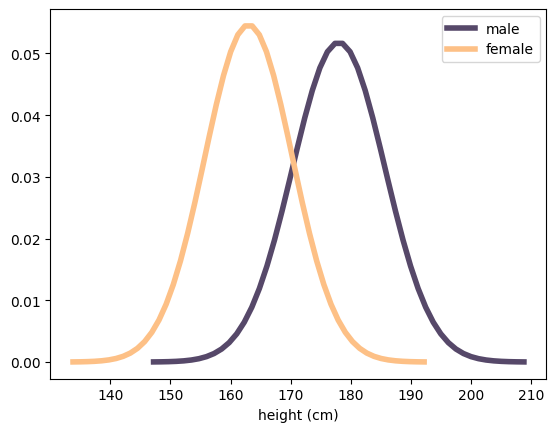

In [61]:
#Male height
xs, yx = evaluate_pdf(male_heights)
plt.plot(xs, yx, label='male', linewidth=4, color="#564869") 
 
#Female height 
xs, yx = evaluate_pdf(female_heights)
plt.plot(xs, yx, label='female', linewidth=4, color='#fdc086')
 
plt.xlabel('height (cm)')
plt.legend()
plt.show()

In [62]:
male_sample= male_heights.rvs(1000)
female_sample= female_heights.rvs(1000)

In [63]:
mean1,sd1=male_sample.mean(),male_sample.std()
mean1,sd1

(np.float64(177.88791390576085), np.float64(7.222274730410271))

In [64]:
mean2,sd2=female_sample.mean(),female_sample.std()
mean2,sd2

(np.float64(162.91903182040372), np.float64(7.261850929417819))

> *  *effect size is used to get the difference between two groups under observation*


In [65]:
mean_difference=mean1-mean2
mean_difference

np.float64(14.968882085357137)

In [66]:
#quantifying the differnce
# percentage the mean --relative
#using the male sample mean
relative_difference=mean_difference/mean1
percentage_difference=relative_difference*100
percentage_difference

np.float64(8.414783082614122)

In [67]:
#using the female sample mean
relative_difference2=mean_difference/mean2
percentage_difference2=relative_difference2*100
percentage_difference2

np.float64(9.18792722869745)

In [68]:
simple_overlap_ratio=(mean1+mean2)/2
simple_overlap_ratio

np.float64(170.4034728630823)

In [69]:
overlap_ratio=(sd1*mean2+sd2*mean1)/(sd1+sd2)
overlap_ratio

np.float64(170.42392323303363)

In [70]:
#cohens d function
def cohensd (group1,group2):
    difference_mean=group1.mean()-group2.mean()
    n1=len(group1)
    n2=len(group2)
    v1=group1.var()
    v2=group2.var()
    pooled_variance=(n1*v1+n2*v2)/(n1+n2)
    pooled_std=np.sqrt(pooled_variance)
    cohensd=difference_mean/pooled_std
    return cohensd

In [71]:
#call the function
d=cohensd(male_sample,female_sample)
d

np.float64(2.0669285200851877)

### Anova
* ANOVA **(ANALYSIS OF VARIANCE)**
* It is a statistical test used to compare means among three or more groups.
* its used to determine if theres a significance difference between the means of multiple groups.
* **F-Statistic** :Measures the ratio between group variation to within group variation.
* **p-value** : indicates the probability of observing results by chance.

In [72]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import statsmodels.api as sm #statsmodels for runnign anova
from statsmodels.formula.api import ols #ols(ordinary list square  ) for regretion

In [73]:
#loading dataset
df = pd.read_csv('IT_salaries.csv')
df.head()

,S,X,E,M
0,13876,1,1,1
1,11608,1,3,0
2,18701,1,3,1
3,11283,1,2,0
4,11767,1,3,0


In [74]:
formula='S~C(E)+C(M)+X'
lm=ols(formula,df).fit()
table=sm.stats.anova_lm(lm, typ=2)
table

,sum_sq,df,F,PR(>F)
C(E),9.152624e+07,2.0,43.351589,7.672450e-11
C(M),5.075724e+08,1.0,480.825394,2.901444e-24
X,3.380979e+08,1.0,320.281524,5.546313e-21
Residual,4.328072e+07,41.0,NaN,NaN


Scenario:

 >A company ran three online ad campaigns — A, B, and C.
 
 >You have conversion rates (%) from 10 cities for each campaign.

Task:
 >Write Python code to check if the mean conversion rates differ significantly among the campaigns using one-way ANOVA.

In [75]:
# Sample data
campaign_A = [12, 15, 14, 10, 13, 15, 11, 14, 13, 16]
campaign_B = [18, 17, 16, 15, 20, 19, 18, 16, 17, 19]
campaign_C = [10, 9, 11, 10, 12, 9, 11, 8, 10, 9]

f_stats, p_value=f_oneway(campaign_A,campaign_B,campaign_C)
print(f_stats,p_value)
alpha=0.05
if p_value<alpha:
    print('reject the null hypothesis')
else:
    print('fail to reject the null hypothesis')

57.973333333333386 1.692627434604139e-10
reject the null hypothesis


In [76]:
observed=0.55 #observed probability of getting a heads in a coin flip
expected=0.5 #assumption of getting of getting the probability of heads in a coin flip
prob=expected
rows=[]
for n in [10,20,50,500]:#different sample sizes
    std=np.sqrt(n*prob*(1-prob)) #std of binomial dist is the sqrt of n*p*(1-p)
    cohens_d=((n*observed)-(n*expected))/std #difference of means/pooled std deviation
    rows.append({'Effect size':cohens_d,'Sample size':n}) 
data=pd.DataFrame(rows)
data.head()

,Effect size,Sample size
0,0.316228,10
1,0.447214,20
2,0.707107,50
3,2.236068,500


In [77]:
dict_rows={}
for n in [10,20,50,500]:
    temp_dict={}#temporary dictionary to store cohensd of alternative hypothesis
    for observed in [ .51, .55 , .6, .65, .7, .75, .8, .85, .9]:
        std=np.sqrt(n*prob*(1-prob))
        d=(observed*n-expected*n)/std#this is correct
        temp_dict[observed]=d
    dict_rows[n]=temp_dict
print('Hypothetical effect sizes for various alternative hypothesis')
df=pd.DataFrame.from_dict(dict_rows,orient='index')
df.head()



Hypothetical effect sizes for various alternative hypothesis


,0.51,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
10,0.063246,0.316228,0.632456,0.948683,1.264911,1.581139,1.897367,2.213594,2.529822
20,0.089443,0.447214,0.894427,1.341641,1.788854,2.236068,2.683282,3.130495,3.577709
50,0.141421,0.707107,1.414214,2.121320,2.828427,3.535534,4.242641,4.949747,5.656854
500,0.447214,2.236068,4.472136,6.708204,8.944272,11.180340,13.416408,15.652476,17.888544


In [78]:
data=pd.read_csv(r'house_prices_dataset.csv')
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,zipcode,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,98001,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,98003,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,98002,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,98004,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,98005,47.701306,-122.416623,1314784.23


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        1000 non-null   int64  
 1   bathrooms       1000 non-null   int64  
 2   sqft_living     1000 non-null   int64  
 3   sqft_lot        1000 non-null   int64  
 4   floors          1000 non-null   int64  
 5   waterfront      1000 non-null   int64  
 6   view            1000 non-null   int64  
 7   condition       1000 non-null   int64  
 8   grade           1000 non-null   int64  
 9   year_built      1000 non-null   int64  
 10  year_renovated  1000 non-null   int64  
 11  zipcode         1000 non-null   int64  
 12  lat             1000 non-null   float64
 13  long            1000 non-null   float64
 14  price           1000 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 117.3 KB


***source my_env/Scripts/activate***

***pip install -r requirements.txt***


In [80]:
data.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'year_built',
       'year_renovated', 'zipcode', 'lat', 'long', 'price'],
      dtype='object')

In [81]:
data=data.drop(columns=['zipcode','lat','long'],axis=1)
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,1314784.23


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        1000 non-null   int64  
 1   bathrooms       1000 non-null   int64  
 2   sqft_living     1000 non-null   int64  
 3   sqft_lot        1000 non-null   int64  
 4   floors          1000 non-null   int64  
 5   waterfront      1000 non-null   int64  
 6   view            1000 non-null   int64  
 7   condition       1000 non-null   int64  
 8   grade           1000 non-null   int64  
 9   year_built      1000 non-null   int64  
 10  year_renovated  1000 non-null   int64  
 11  price           1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


In [83]:
data['condition'].value_counts()

condition
5    216
2    207
4    199
1    190
3    188
Name: count, dtype: int64

In [84]:
data['waterfront'].value_counts()

waterfront
0    893
1    107
Name: count, dtype: int64

In [85]:
data['grade'].value_counts()

grade
12    111
1      95
3      91
10     90
8      86
4      85
5      80
9      80
6      76
11     75
7      72
2      59
Name: count, dtype: int64

In [86]:
data['view'].value_counts()

view
1    265
0    259
3    250
2    226
Name: count, dtype: int64

* which data are categorical and which are numerical? 
grade,condition,waterfront are categorical
* numerical data- price,sqft_living,sqft_lot,floors


In [90]:
data.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'year_built',
       'year_renovated', 'price'],
      dtype='object')

In [92]:
formular='price~bedrooms+bathrooms+sqft_living+sqft_lot+floors+year_built+year_renovated+C(grade)+C(condition)+C(waterfront)+C(view)'
lm=ols(formular,data).fit()
table=sm.stats.anova_lm(lm,typ=2)
table

,sum_sq,df,F,PR(>F)
C(grade),7.624866e+11,11.0,183.316235,2.858685e-228
C(condition),2.041546e+11,4.0,134.977239,9.551189e-92
C(waterfront),9.166195e+11,1.0,2424.099877,2.058608e-266
C(view),1.776019e+10,3.0,15.656251,5.974182e-10
bedrooms,4.708068e+11,1.0,1245.099809,2.690992e-176
bathrooms,6.161723e+10,1.0,162.953472,1.290603e-34
sqft_living,1.015938e+14,1.0,268675.916515,0.000000e+00
sqft_lot,1.959280e+09,1.0,5.181529,2.304476e-02
floors,4.142126e+07,1.0,0.109543,7.407363e-01
year_built,5.214565e+06,1.0,0.013790,9.065413e-01
